# 4-Model Comparison From Existing CSVs

This notebook reads existing outputs in `training_outputs/*.csv` and builds comparison graphs for:
- `EfficientNetB0`
- `MobileNetV3Small`
- `ResNet50`
- `MobileNetV2`

No training is performed here.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
OUT_DIR = PROJECT_ROOT / 'training_outputs'
FIG_DIR = OUT_DIR / 'figures' / 'csv_model_comparison'
FIG_DIR.mkdir(parents=True, exist_ok=True)

SEED_PATH = OUT_DIR / 'seed_metrics.csv'
BACKBONE_SUMMARY_PATH = OUT_DIR / 'backbone_summary.csv'
CROSS_SUMMARY_PATH = OUT_DIR / 'cross_rotation_summary.csv'
FOLD_METRICS_PATH = OUT_DIR / 'fold_metrics.csv'

MODEL_ORDER = ['EfficientNetB0', 'MobileNetV3Small', 'ResNet50', 'MobileNetV2']

print('Output dir:', OUT_DIR)
print('Figure dir:', FIG_DIR)

Output dir: e:\Thesis Code\training_outputs
Figure dir: e:\Thesis Code\training_outputs\figures\csv_model_comparison


In [2]:
seed_df = pd.read_csv(SEED_PATH)
backbone_summary_df = pd.read_csv(BACKBONE_SUMMARY_PATH)
cross_summary_df = pd.read_csv(CROSS_SUMMARY_PATH)
fold_metrics_df = pd.read_csv(FOLD_METRICS_PATH)

print('seed_metrics rows:', len(seed_df))
print('backbone_summary rows:', len(backbone_summary_df))
print('cross_rotation_summary rows:', len(cross_summary_df))
print('fold_metrics rows:', len(fold_metrics_df))

present = sorted(seed_df['backbone'].dropna().astype(str).unique().tolist())
print('Backbones in seed_metrics:', present)

seed_metrics rows: 27
backbone_summary rows: 4
cross_rotation_summary rows: 4
fold_metrics rows: 7
Backbones in seed_metrics: ['EfficientNetB0', 'MobileNetV2', 'MobileNetV3Small', 'ResNet50']


In [3]:
# Keep only cross_rotation rows for fair apples-to-apples comparison
seed_cross = seed_df.loc[seed_df['split_mode'].astype(str).eq('cross_rotation')].copy()

# Respect display order while keeping only available backbones
available_order = [m for m in MODEL_ORDER if m in set(seed_cross['backbone'].astype(str).unique())]

for df in [seed_cross, cross_summary_df, fold_metrics_df, backbone_summary_df]:
    if 'backbone' in df.columns:
        df['backbone'] = pd.Categorical(df['backbone'].astype(str), categories=available_order, ordered=True)

seed_cross = seed_cross.sort_values(['backbone', 'split_name', 'seed'])
cross_summary_df = cross_summary_df.sort_values('backbone')
fold_metrics_df = fold_metrics_df.sort_values(['backbone', 'split_name'])

print('Ordered backbones:', available_order)

Ordered backbones: ['EfficientNetB0', 'MobileNetV3Small', 'ResNet50', 'MobileNetV2']


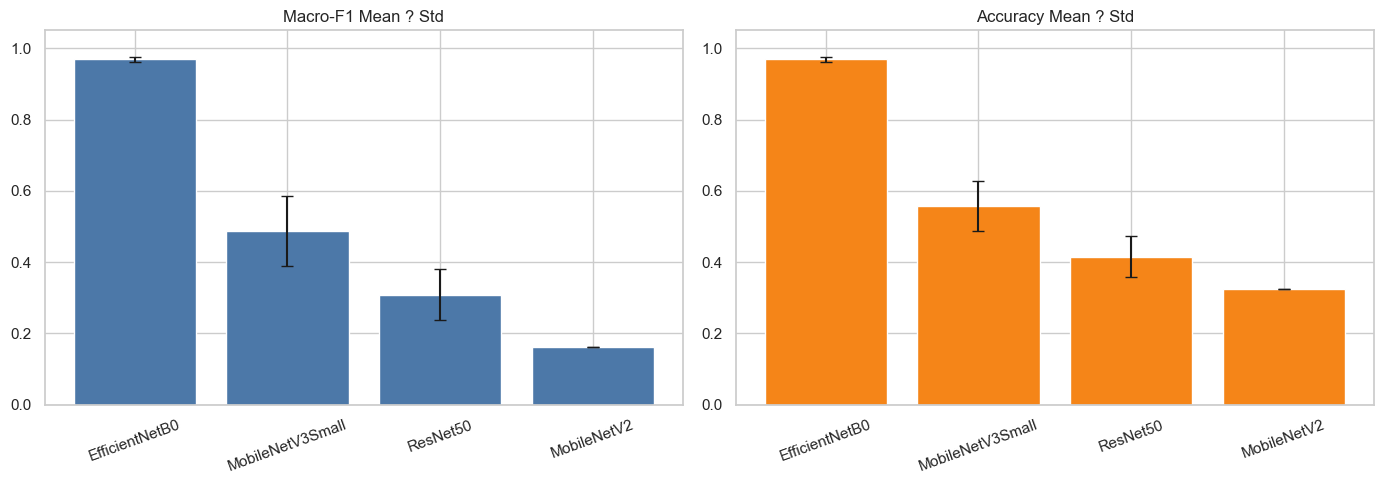

In [4]:
# 1) Mean Macro-F1 and Accuracy (cross-rotation summary)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if {'macro_f1_mean', 'macro_f1_std'}.issubset(cross_summary_df.columns):
    axes[0].bar(
        cross_summary_df['backbone'].astype(str),
        cross_summary_df['macro_f1_mean'],
        yerr=cross_summary_df['macro_f1_std'].fillna(0),
        capsize=4,
        color='#4C78A8'
    )
    axes[0].set_title('Macro-F1 Mean ? Std')
    axes[0].set_ylim(0, 1.05)
    axes[0].tick_params(axis='x', rotation=20)

if {'accuracy_mean', 'accuracy_std'}.issubset(cross_summary_df.columns):
    axes[1].bar(
        cross_summary_df['backbone'].astype(str),
        cross_summary_df['accuracy_mean'],
        yerr=cross_summary_df['accuracy_std'].fillna(0),
        capsize=4,
        color='#F58518'
    )
    axes[1].set_title('Accuracy Mean ? Std')
    axes[1].set_ylim(0, 1.05)
    axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / '01_macrof1_accuracy_mean_std.png', dpi=200)
plt.show()

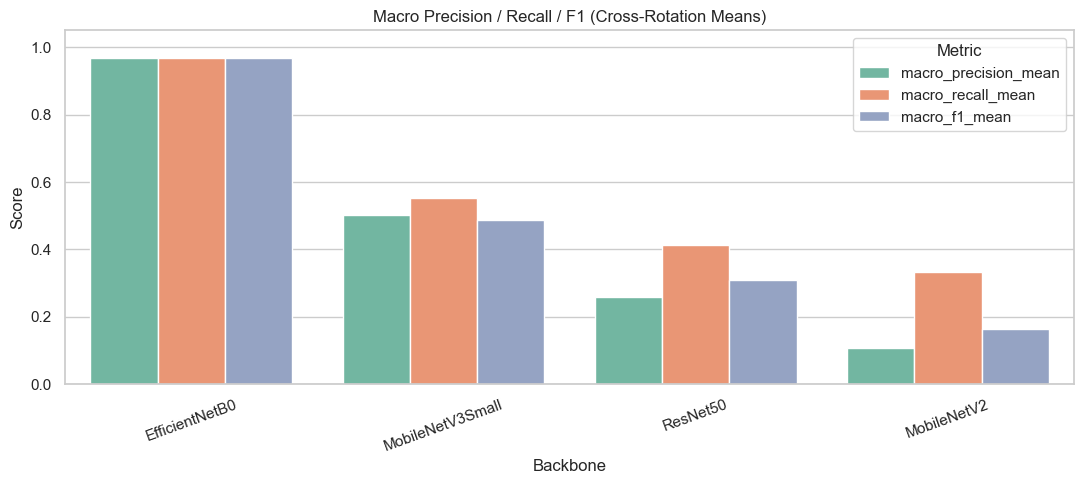

In [5]:
# 2) Precision / Recall / F1 grouped bars
metrics = ['macro_precision_mean', 'macro_recall_mean', 'macro_f1_mean']
plot_df = cross_summary_df[['backbone'] + [m for m in metrics if m in cross_summary_df.columns]].copy()
long_df = plot_df.melt(id_vars='backbone', var_name='metric', value_name='value')

plt.figure(figsize=(11, 5))
sns.barplot(data=long_df, x='backbone', y='value', hue='metric', palette='Set2')
plt.ylim(0, 1.05)
plt.title('Macro Precision / Recall / F1 (Cross-Rotation Means)')
plt.xlabel('Backbone')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.legend(title='Metric')
plt.tight_layout()
plt.savefig(FIG_DIR / '02_precision_recall_f1_grouped.png', dpi=200)
plt.show()

C:\Users\jazre\AppData\Local\Temp\ipykernel_35876\46999596.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for backbone, sub in fold_plot.groupby('backbone'):


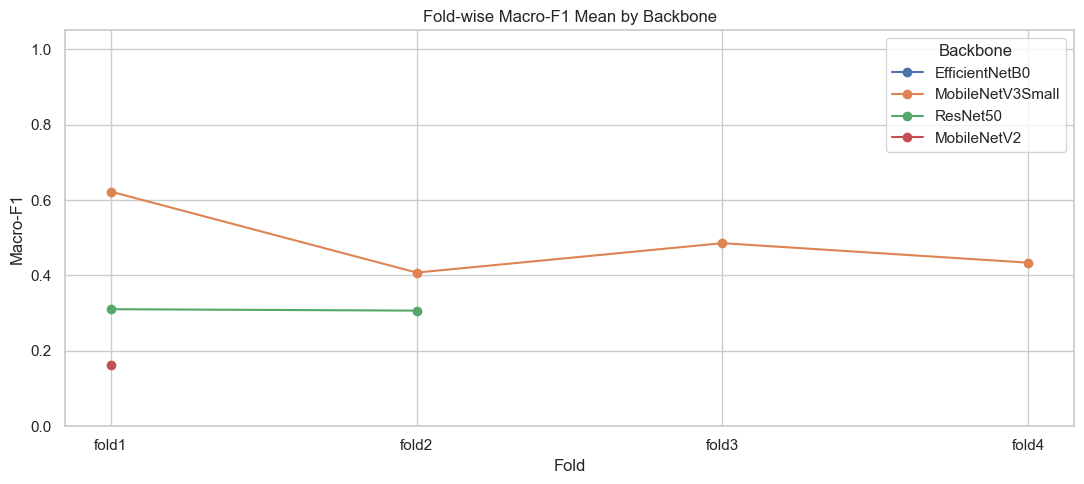

In [6]:
# 3) Fold-wise Macro-F1 comparison (from fold_metrics)
fold_plot = fold_metrics_df.loc[fold_metrics_df['split_mode'].astype(str).eq('cross_rotation')].copy()

plt.figure(figsize=(11, 5))
for backbone, sub in fold_plot.groupby('backbone'):
    plt.plot(sub['split_name'].astype(str), sub['macro_f1_mean'], marker='o', label=str(backbone))

plt.title('Fold-wise Macro-F1 Mean by Backbone')
plt.xlabel('Fold')
plt.ylabel('Macro-F1')
plt.ylim(0, 1.05)
plt.legend(title='Backbone')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_foldwise_macrof1.png', dpi=200)
plt.show()

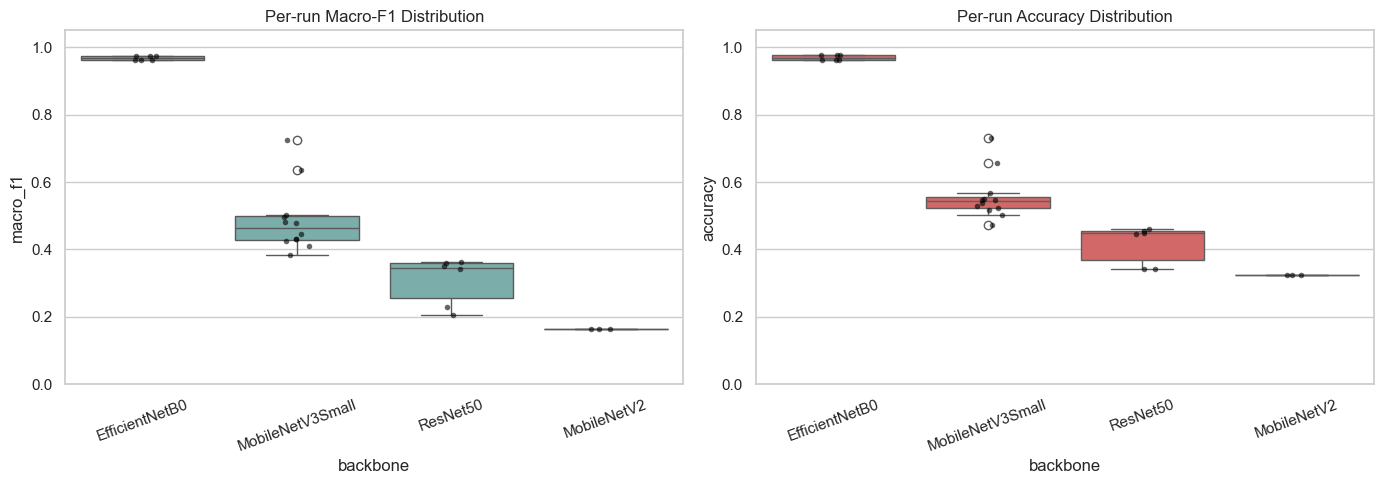

In [7]:
# 4) Per-run distribution (seed-level) for Macro-F1 and Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=seed_cross, x='backbone', y='macro_f1', ax=axes[0], color='#72B7B2')
sns.stripplot(data=seed_cross, x='backbone', y='macro_f1', ax=axes[0], color='black', size=4, alpha=0.6)
axes[0].set_title('Per-run Macro-F1 Distribution')
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=seed_cross, x='backbone', y='accuracy', ax=axes[1], color='#E45756')
sns.stripplot(data=seed_cross, x='backbone', y='accuracy', ax=axes[1], color='black', size=4, alpha=0.6)
axes[1].set_title('Per-run Accuracy Distribution')
axes[1].set_ylim(0, 1.05)
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / '04_seed_level_distributions.png', dpi=200)
plt.show()

C:\Users\jazre\AppData\Local\Temp\ipykernel_35876\3620398479.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  seed_cross


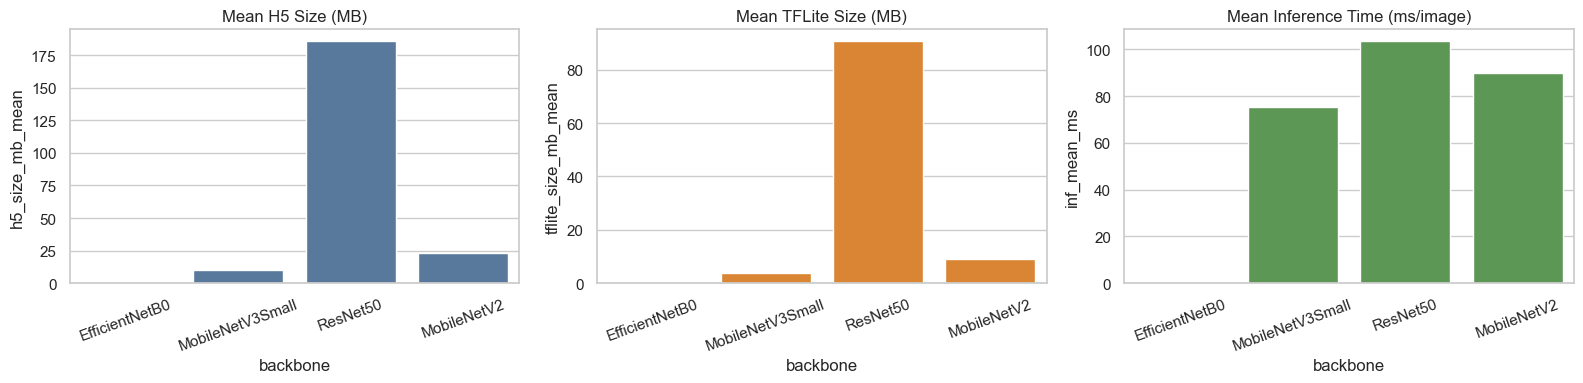

In [8]:
# 5) Model size and inference speed (if available)
size_speed = (
    seed_cross
    .groupby('backbone', as_index=False)
    .agg(
        h5_size_mb_mean=('h5_size_mb', 'mean'),
        tflite_size_mb_mean=('tflite_size_mb', 'mean'),
        inf_mean_ms=('inference_mean_ms_per_image', 'mean')
    )
)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.barplot(data=size_speed, x='backbone', y='h5_size_mb_mean', ax=axes[0], color='#4C78A8')
axes[0].set_title('Mean H5 Size (MB)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=size_speed, x='backbone', y='tflite_size_mb_mean', ax=axes[1], color='#F58518')
axes[1].set_title('Mean TFLite Size (MB)')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=size_speed, x='backbone', y='inf_mean_ms', ax=axes[2], color='#54A24B')
axes[2].set_title('Mean Inference Time (ms/image)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIG_DIR / '05_size_and_speed.png', dpi=200)
plt.show()

In [9]:
# 6) Export a compact comparison table used for reporting
comparison_cols = [
    'backbone', 'runs', 'accuracy_mean', 'accuracy_std',
    'macro_precision_mean', 'macro_precision_std',
    'macro_recall_mean', 'macro_recall_std',
    'macro_f1_mean', 'macro_f1_std'
]

comp_table = cross_summary_df[[c for c in comparison_cols if c in cross_summary_df.columns]].copy()
comp_table = comp_table.sort_values('macro_f1_mean', ascending=False)
comp_table.to_csv(OUT_DIR / 'four_model_comparison_table.csv', index=False)

comp_table

,backbone,runs,accuracy_mean,accuracy_std,macro_precision_mean,macro_precision_std,macro_recall_mean,macro_recall_std,macro_f1_mean,macro_f1_std
0,EfficientNetB0,6,0.968750,0.007504,0.968750,0.007175,0.968750,0.007175,0.968750,0.007175
2,MobileNetV3Small,12,0.556821,0.070410,0.501314,0.145223,0.552047,0.071649,0.487286,0.099502
3,ResNet50,6,0.415733,0.057470,0.258664,0.069720,0.412592,0.055711,0.308539,0.071354
1,MobileNetV2,3,0.323711,0.000000,0.107904,0.000000,0.333333,0.000000,0.163032,0.000000
